# Exercício 1

In [13]:
import torch

def f_1(x):
  return torch.sin(2*x) + torch.cos(3*x)

def f_2(x):
  return 10 * torch.pow(x,5) + 5 * torch.pow(x,4) + 2 * torch.pow(x,3) - 0.5 * torch.pow(x,2) + 3*x + 2

In [14]:
N = 1000

x = torch.linspace(0, 5, N).unsqueeze(1)
y = f_1(x)

perm = torch.randperm(N)
x = x[perm]
y = y[perm]

train_size = int(0.8 * N)

x_train = x[:train_size]
y_train = y[:train_size]

x_val = x[train_size:]
y_val = y[train_size:]

In [15]:
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

train_dataset = TensorDataset(x_train, y_train)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

model = MLP()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [16]:
epochs = 500


train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    batch_losses = []

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        pred = model(batch_x)
        loss = criterion(pred, batch_y)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    epoch_train_loss = sum(batch_losses) / len(batch_losses)
    train_losses.append(epoch_train_loss)

    model.eval()
    with torch.no_grad():
        val_pred = model(x_val)
        val_loss = criterion(val_pred, y_val)
        val_losses.append(val_loss.item())

    if (epoch + 1) % 50 == 0:
        print(f'Época [{epoch+1}/{epochs}], Loss Treino: {epoch_train_loss:.4f}, Loss Val: {val_loss.item():.4f}')

Época [50/500], Loss Treino: 0.2841, Loss Val: 0.2527
Época [100/500], Loss Treino: 0.0136, Loss Val: 0.0102
Época [150/500], Loss Treino: 0.0010, Loss Val: 0.0022
Época [200/500], Loss Treino: 0.0004, Loss Val: 0.0003
Época [250/500], Loss Treino: 0.0011, Loss Val: 0.0008
Época [300/500], Loss Treino: 0.0002, Loss Val: 0.0002
Época [350/500], Loss Treino: 0.0004, Loss Val: 0.0003
Época [400/500], Loss Treino: 0.0002, Loss Val: 0.0001
Época [450/500], Loss Treino: 0.0003, Loss Val: 0.0002
Época [500/500], Loss Treino: 0.0002, Loss Val: 0.0002


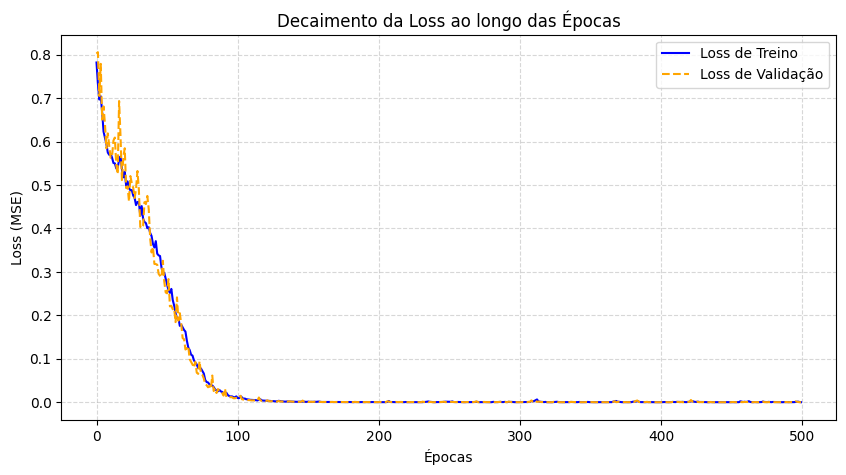

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Loss de Treino', color='blue')
plt.plot(val_losses, label='Loss de Validação', color='orange', linestyle='--')


plt.title("Decaimento da Loss ao longo das Épocas")
plt.xlabel("Épocas")
plt.ylabel("Loss (MSE)")
plt.legend()

plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.show()

In [18]:
print(val_losses[-1])

0.00022500134946312755


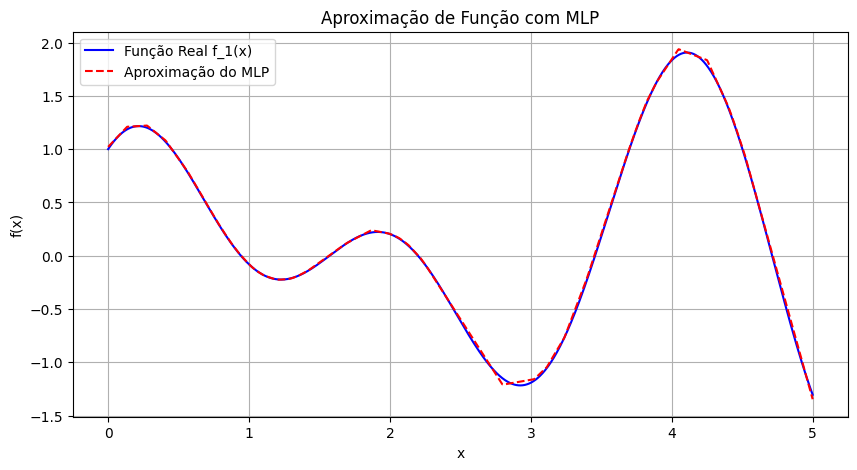

In [19]:
import matplotlib.pyplot as plt

x_plot = torch.linspace(0, 5, 1000).unsqueeze(1)
y_real = f_1(x_plot)

model.eval()
with torch.no_grad():
    y_pred = model(x_plot)

plt.figure(figsize=(10, 5))
plt.plot(x_plot.numpy(), y_real.numpy(), label="Função Real f_1(x)", color="blue")
plt.plot(x_plot.numpy(), y_pred.numpy(), label="Aproximação do MLP", color="red", linestyle="--")
plt.title("Aproximação de Função com MLP")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

# Função 2

In [20]:
N = 1000

x = torch.linspace(0, 5, N).unsqueeze(1)
y = f_2(x)

perm = torch.randperm(N)
x = x[perm]
y = y[perm]

train_size = int(0.8 * N)

x_train = x[:train_size]
y_train = y[:train_size]

x_val = x[train_size:]
y_val = y[train_size:]

x_mean, x_std = x_train.mean(), x_train.std()
y_mean, y_std = y_train.mean(), y_train.std()

# normalizando dados de treino e de validação (f_2(x) produz valores muito grandes)

x_train_norm = (x_train - x_mean) / x_std
y_train_norm = (y_train - y_mean) / y_std

x_val_norm = (x_val - x_mean) / x_std
y_val_norm = (y_val - y_mean) / y_std

In [21]:
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

train_dataset = TensorDataset(x_train_norm, y_train_norm)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

model = MLP()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [22]:
epochs = 500


train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    batch_losses = []

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        pred = model(batch_x)
        loss = criterion(pred, batch_y)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    epoch_train_loss = sum(batch_losses) / len(batch_losses)
    train_losses.append(epoch_train_loss)

    model.eval()
    with torch.no_grad():
        val_pred = model(x_val_norm)
        val_loss = criterion(val_pred, y_val_norm)
        val_losses.append(val_loss.item())

    if (epoch + 1) % 50 == 0:
        print(f'Época [{epoch+1}/{epochs}], Loss Treino: {epoch_train_loss:.4f}, Loss Val: {val_loss.item():.4f}')

Época [50/500], Loss Treino: 0.0005, Loss Val: 0.0009
Época [100/500], Loss Treino: 0.0001, Loss Val: 0.0001
Época [150/500], Loss Treino: 0.0000, Loss Val: 0.0001
Época [200/500], Loss Treino: 0.0000, Loss Val: 0.0000
Época [250/500], Loss Treino: 0.0000, Loss Val: 0.0000
Época [300/500], Loss Treino: 0.0000, Loss Val: 0.0000
Época [350/500], Loss Treino: 0.0000, Loss Val: 0.0000
Época [400/500], Loss Treino: 0.0000, Loss Val: 0.0000
Época [450/500], Loss Treino: 0.0000, Loss Val: 0.0000
Época [500/500], Loss Treino: 0.0000, Loss Val: 0.0000


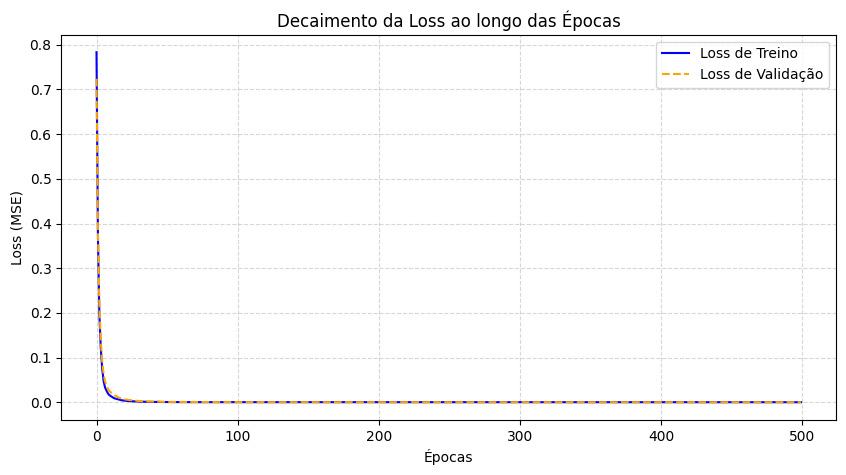

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Loss de Treino', color='blue')
plt.plot(val_losses, label='Loss de Validação', color='orange', linestyle='--')


plt.title("Decaimento da Loss ao longo das Épocas")
plt.xlabel("Épocas")
plt.ylabel("Loss (MSE)")
plt.legend()

plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.show()

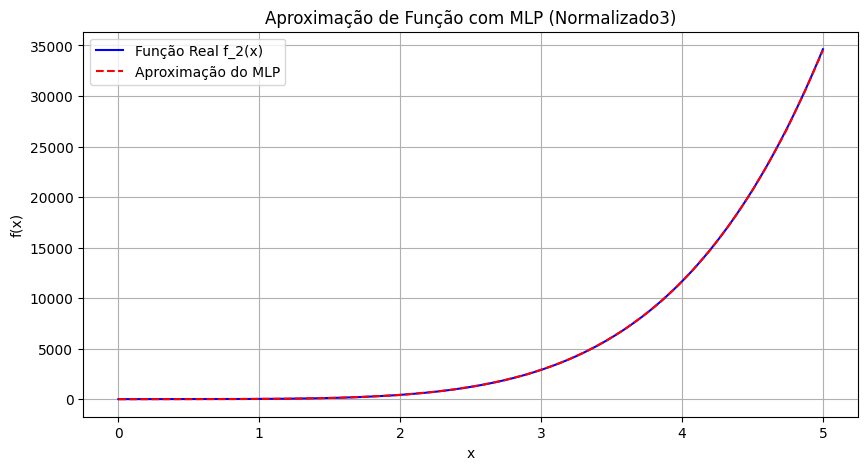

In [24]:
import matplotlib.pyplot as plt

x_plot = torch.linspace(0, 5, 1000).unsqueeze(1)
y_real = f_2(x_plot)

model.eval()
with torch.no_grad():
    x_plot_norm = (x_plot - x_mean) / x_std
    y_pred_norm = model(x_plot_norm)
    y_pred = (y_pred_norm * y_std) + y_mean

plt.figure(figsize=(10, 5))


plt.plot(x_plot.numpy(), y_real.numpy(), label="Função Real f_2(x)", color="blue")
plt.plot(x_plot.numpy(), y_pred.numpy(), label="Aproximação do MLP", color="red", linestyle="--")
plt.title("Aproximação de Função com MLP (Normalizado3)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()